# Titanic Experiment 18

가설:
fare 원본값을 유지하면서 LogFare를 추가하면
Fare의 원본 정보와 로그 변환 정보를 동시에 활용할 수 있어
AUC와 일반화 성능이 개선될 수 있다.

변경사항:
+ LogFare
fare 유지


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from common.utils import train_test_split_by_target
from common.title_feature_experiments import fit_feature_model, model_metrics, five_fold_compare
from common.feature_experiments import fit_cat

ROOT = Path.cwd()
TRAIN_PATH = ROOT / "csv" / "train.csv"
TEST_PATH = ROOT / "csv" / "test.csv"
SUBMISSION_PATH = ROOT / "csv" / "submission.csv"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUBMISSION_PATH)

target_col = next(col for col in train.columns if col not in test.columns)
id_col = submission.columns[0]
feature_name = "LogFare"
print("train:", train.shape, "test:", test.shape, "submission:", submission.shape)
print("target:", target_col, "ID:", id_col, "candidate:", feature_name)


train: (916, 12) test: (393, 11) submission: (393, 2)
target: survived ID: passengerid candidate: LogFare


In [2]:
train["LogFare"] = np.log1p(train["fare"])
test["LogFare"] = np.log1p(test["fare"])

assert "fare" in train.columns and "fare" in test.columns
assert "LogFare" in train.columns and "LogFare" in test.columns
print("LogFare 생성 완료")
print("train LogFare missing count:", train["LogFare"].isna().sum())
print("test LogFare missing count:", test["LogFare"].isna().sum())


LogFare 생성 완료
train LogFare missing count: 0
test LogFare missing count: 1


In [3]:
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]

assert set(y.unique()) == {0, 1}
assert X.columns.equals(X_test_raw.columns)
assert "LogFare" in X_tr_raw.columns and "LogFare" in X_valid_raw.columns
assert len(train_part) == 687 and len(valid_part) == 229
print("train split:", X_tr_raw.shape, "validation split:", X_valid_raw.shape)
print(y_tr.value_counts(normalize=True).sort_index().to_string())


train split: (687, 11) validation split: (229, 11)
survived
0    0.621543
1    0.378457


## 1. Base와 LogFare 후보 모델 비교

기존 Feature와 모델 설정은 그대로 유지하고, `fare`는 유지한 채 `LogFare`만 추가합니다.


In [4]:
_, base_model, X_base_train, X_base_valid = fit_feature_model(X_tr_raw, y_tr, X_valid_raw, None)
_, candidate_model, X_candidate_train, X_candidate_valid = fit_feature_model(X_tr_raw, y_tr, X_valid_raw, feature_name)

assert base_model.get_all_params() == candidate_model.get_all_params()

base_result = model_metrics(base_model, X_base_train, y_tr, X_base_valid, y_valid)
candidate_result = model_metrics(candidate_model, X_candidate_train, y_tr, X_candidate_valid, y_valid)

print("Base Train AUC:", round(base_result["train_auc"], 6))
print("Base Validation AUC:", round(base_result["validation_auc"], 6))
print("Candidate Train AUC:", round(candidate_result["train_auc"], 6))
print("Candidate Validation AUC:", round(candidate_result["validation_auc"], 6))


Base Train AUC: 0.965128
Base Validation AUC: 0.900309
Candidate Train AUC: 0.965128
Candidate Validation AUC: 0.900309


In [5]:
def classification_metrics(result):
    prediction = result["valid_prediction"]
    tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_valid, prediction),
        "precision": precision_score(y_valid, prediction, zero_division=0),
        "recall": recall_score(y_valid, prediction, zero_division=0),
        "f1": f1_score(y_valid, prediction, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

base_class = classification_metrics(base_result)
candidate_class = classification_metrics(candidate_result)
print("Base metrics:", base_class)
print("Candidate metrics:", candidate_class)


Base metrics: {'accuracy': 0.8558951965065502, 'precision': 0.8192771084337349, 'recall': 0.7906976744186046, 'f1': 0.8047337278106509, 'tn': 128, 'fp': 15, 'fn': 18, 'tp': 68}
Candidate metrics: {'accuracy': 0.8558951965065502, 'precision': 0.8192771084337349, 'recall': 0.7906976744186046, 'f1': 0.8047337278106509, 'tn': 128, 'fp': 15, 'fn': 18, 'tp': 68}


## 2. 5-Fold CV (기존 구조 유지)

`LogFare`만 추가한 후보와 기존 Base를 같은 fold에서 공정하게 비교한다.


In [6]:
fold_table, cv_summary = five_fold_compare(X, y, feature_name)
fold_pivot = fold_table.pivot(index="fold", columns="model", values="auc")
fold_pivot["Difference"] = fold_pivot["Candidate"] - fold_pivot["Base"]
print("\n[5-Fold AUC]")
print(fold_pivot.to_string(float_format=lambda value: f"{value:.6f}"))
print("\n[CV 요약]")
print(cv_summary.to_string(float_format=lambda value: f"{value:.6f}"))


Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료

[5-Fold AUC]
model     Base  Candidate  Difference
fold                                 
1     0.889724   0.889724    0.000000
2     0.913107   0.913107    0.000000
3     0.875222   0.875222    0.000000
4     0.904144   0.904144    0.000000
5     0.909484   0.909484    0.000000

[CV 요약]
              mean      std
model                      
Base      0.898336 0.015689
Candidate 0.898336 0.015689


In [7]:
metrics = ["Train AUC", "Validation AUC", "Gap", "CV Mean", "CV Std"]
base_values = [
    base_result["train_auc"], base_result["validation_auc"], base_result["gap"],
    cv_summary.loc["Base", "mean"], cv_summary.loc["Base", "std"],
]
candidate_values = [
    candidate_result["train_auc"], candidate_result["validation_auc"], candidate_result["gap"],
    cv_summary.loc["Candidate", "mean"], cv_summary.loc["Candidate", "std"],
]
comparison = pd.DataFrame({"Metric": metrics, "Base": base_values, "Candidate": candidate_values})
comparison["Difference"] = comparison["Candidate"] - comparison["Base"]
print(comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

with (ROOT / "results" / "titanic_16_summary.json").open("r", encoding="utf-8") as f:
    previous_best = json.load(f)

prev_val = previous_best["champion_holdout"]["validation_auc"]
prev_cv = previous_best["champion_cv_mean"]
print(f"\nPrevious Best Validation AUC: {prev_val:.6f}")
print(f"Titanic 18 Validation AUC: {candidate_result['validation_auc']:.6f}")
print(f"Difference: {candidate_result['validation_auc'] - prev_val:+.6f}")
print(f"\nPrevious Best CV Mean: {prev_cv:.6f}")
print(f"Titanic 18 CV Mean: {cv_summary.loc['Candidate', 'mean']:.6f}")
print(f"Difference: {cv_summary.loc['Candidate', 'mean'] - prev_cv:+.6f}")


        Metric     Base  Candidate  Difference
     Train AUC 0.965128   0.965128    0.000000
Validation AUC 0.900309   0.900309    0.000000
           Gap 0.064819   0.064819    0.000000
       CV Mean 0.898336   0.898336    0.000000
        CV Std 0.015689   0.015689    0.000000

Previous Best Validation AUC: 0.903643
Titanic 18 Validation AUC: 0.900309
Difference: -0.003334

Previous Best CV Mean: 0.906275
Titanic 18 CV Mean: 0.898336
Difference: -0.007938


## 3. 최종 Train/Test 재학습 및 제출 파일 생성

현재 실험의 `LogFare`를 전체 train에 fit하고, test에 transform해서 Kaggle submission용 결과를 생성한다.


In [8]:
from common.title_feature_experiments import TitleFeaturePreprocessor

full_prep = TitleFeaturePreprocessor(feature_name)
X_full = full_prep.fit_transform(X)
X_test = full_prep.transform(X_test_raw)

assert X_full.columns.equals(X_test.columns)
assert np.isfinite(X_full.to_numpy()).all()
assert np.isfinite(X_test.to_numpy()).all()
print("전체 train/test 변환 검증 완료:", X_full.shape, X_test.shape)

full_model = fit_cat(X_full, y)
positive_index = list(full_model.classes_).index(1)
test_probability = full_model.predict_proba(X_test)[:, positive_index]

result = pd.DataFrame({
    id_col: test[id_col],
    target_col: test_probability,
})
result.columns = submission.columns

result_path = ROOT / "submission" / "titanic_result_18.csv"
result.to_csv(result_path, index=False)
print("생성 파일:", result_path)
print("result shape:", result.shape)
print(result.head().to_string(index=False))


전체 train/test 변환 검증 완료: (916, 13) (393, 13)
생성 파일: c:\dev\study\machine_learning\submission\titanic_result_18.csv
result shape: (393, 2)
 passengerid  survived
         916  0.829912
         917  0.895525
         918  0.883352
         919  0.079155
         920  0.956514


In [9]:
print("=== 검증 체크 ===")
print("LogFare 생성 여부:", "LogFare" in train.columns and "LogFare" in test.columns)
print("fare 유지 여부:", "fare" in train.columns and "fare" in test.columns)
print("Feature column 일치 여부:", X_full.columns.equals(X_test.columns))
print("NaN/Inf 검사:", np.isfinite(X_full.to_numpy()).all(), np.isfinite(X_test.to_numpy()).all())
print("모델 학습 완료 여부:", full_model is not None)
print("제출 파일 존재 여부:", (ROOT / "submission" / "titanic_result_18.csv").exists())
print("제출 row 수와 test row 수 비교:", len(result), len(test))
print("제출 컬럼 구조:", result.columns.tolist())


=== 검증 체크 ===
LogFare 생성 여부: True
fare 유지 여부: True
Feature column 일치 여부: True
NaN/Inf 검사: True True
모델 학습 완료 여부: True
제출 파일 존재 여부: True
제출 row 수와 test row 수 비교: 393 393
제출 컬럼 구조: ['passengerid', 'survived']


In [10]:
print("\nExperiment: Titanic 18")
print("Added Feature: LogFare")
print("Removed Feature: 없음")
print("Fare: 유지")
print(f"Train AUC: {candidate_result['train_auc']:.6f}")
print(f"Validation AUC: {candidate_result['validation_auc']:.6f}")
print(f"Gap: {candidate_result['gap']:.6f}")
print(f"CV Mean: {cv_summary.loc['Candidate', 'mean']:.6f}")
print(f"CV Std: {cv_summary.loc['Candidate', 'std']:.6f}")

combined_decision = "채택" if candidate_result['validation_auc'] > prev_val and cv_summary.loc['Candidate', 'mean'] > prev_cv else "보류"
print(f"결론: {combined_decision}")
print("생성 파일:")
print("- titanic_18.ipynb")
print("- submission/titanic_result_18.csv")



Experiment: Titanic 18
Added Feature: LogFare
Removed Feature: 없음
Fare: 유지
Train AUC: 0.965128
Validation AUC: 0.900309
Gap: 0.064819
CV Mean: 0.898336
CV Std: 0.015689
결론: 보류
생성 파일:
- titanic_18.ipynb
- submission/titanic_result_18.csv


In [11]:
import shap
import skimage

c:\dev\study\machine_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
explainer = shap.TreeExplainer(full_model)
shap_values = explainer.shap_values(X_test)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_32428\3632369571.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


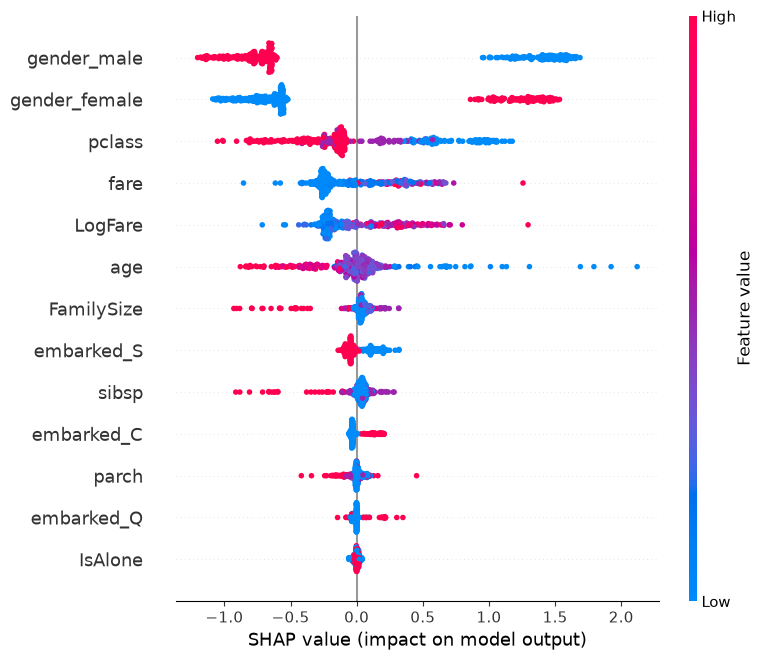

In [14]:
shap_values[1].shape , X_test.shape
shap.summary_plot(shap_values, X_test)

In [ ]:
valid_prediction = model.predict(X_valid_model).astype(int)

# 행(True Label)을 기준으로 정규화
cm = confusion_matrix(
    y_valid,
    valid_prediction,
    labels=[0, 1],
    normalize="true"
)

tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn:.3f}")
print(f"FP: {fp:.3f}")
print(f"FN: {fn:.3f}")
print(f"TP: {tp:.3f}")

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dead", "Survived"]
)

display_cm.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.title("Normalized Validation Confusion Matrix")
plt.tight_layout()
plt.show()